In [1]:
import pandas as pd
import numpy as np
import random
import torch

In [2]:
import ast

In [3]:
sensitive_boundaries_results_path = "/scratch1/smaruj/natural_boundaries/single_sensitive_boundary_results.tsv"
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [9]:
len(df)

4474

In [4]:
import matplotlib.pyplot as plt

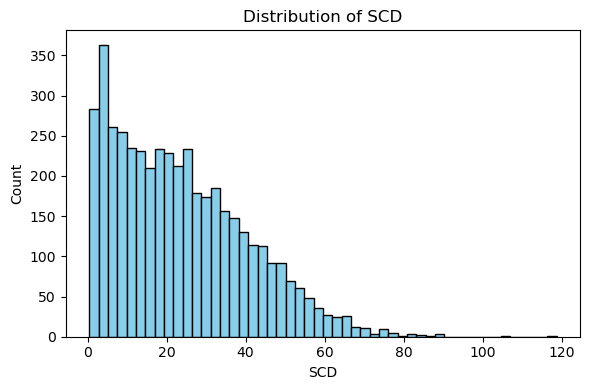

In [5]:
# Plot SCD histogram
plt.figure(figsize=(6, 4))
# plt.hist(filtered_df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.hist(df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of SCD")
plt.xlabel("SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

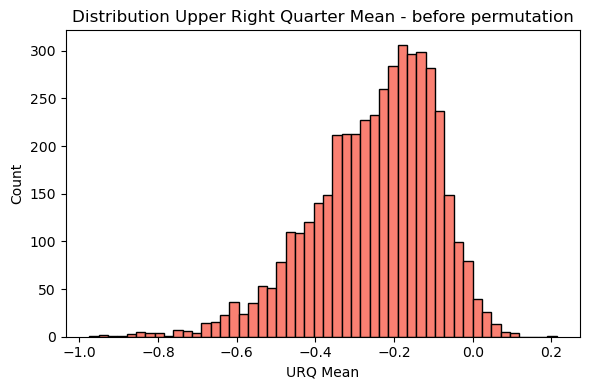

In [6]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
# plt.hist(filtered_df["URQ_mean_og"], bins=50, color="salmon", edgecolor="black")
plt.hist(df["URQ_mean_og"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Upper Right Quarter Mean - before permutation")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

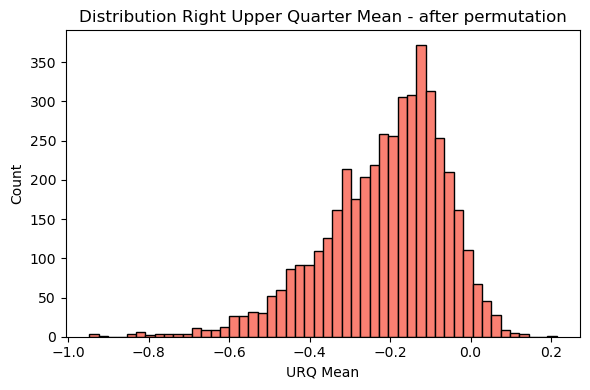

In [7]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
# plt.hist(filtered_df["URQ_mean_perm"], bins=50, color="salmon", edgecolor="black")
plt.hist(df["URQ_mean_perm"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Right Upper Quarter Mean - after permutation")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/SLURM_1378779/ipykernel_2342428/1106430425.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])


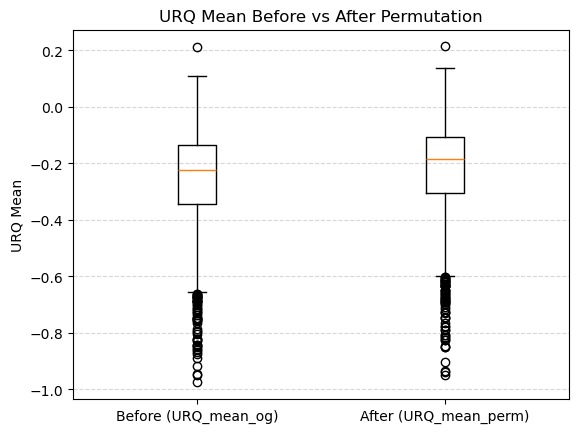

In [8]:
# Create the data in long format for boxplotting
# data_to_plot = [filtered_df['URQ_mean_og'], filtered_df['URQ_mean_perm']]
data_to_plot = [df['URQ_mean_og'], df['URQ_mean_perm']]

# Make the boxplot
plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])
plt.ylabel('URQ Mean')
plt.title('URQ Mean Before vs After Permutation')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## CTCFs analysis

In [10]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [11]:
from pyfaidx import Fasta

In [12]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [13]:
def get_sequence(genome, chrom, start, bin_idx, cropping=64, bin_size=2048):
    bin_start = start + (bin_idx + cropping) * bin_size
    bin_end = bin_start + bin_size
    seq = genome[chrom][bin_start:bin_end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [14]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [15]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [16]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [17]:
from tangermeme.tools import fimo

In [18]:
all_hits = []

# for idx, row in filtered_df.iterrows():
for idx, row in df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    og_URQ = row["URQ_mean_og"]
    perm_URQ = row["URQ_mean_perm"]
    bin_idx = row["disrupted_bin"]

    sequence = get_sequence(genome, chrom, window_start, bin_idx)

    hits = fimo.fimo(
        motifs=motifs_dict,
        sequences=sequence,
        threshold=1e-4,
        reverse_complement=True
    )[0]

    # Only add non-empty results
    if not hits.empty:
        hits = hits.assign(
            chrom=chrom,
            window_start=window_start,
            window_end=window_end,
            bin_idx=bin_idx,
            scd=scd,
            URQ_mean_og=og_URQ,
            URQ_mean_perm=perm_URQ,
            ctcf_count=len(hits)
        )
        all_hits.append(hits)
    else:
        # Add a single row with ctcf_count = 0
        empty_row = {
            "chrom": chrom,
            "window_start": window_start,
            "window_end": window_end,
            "bin_idx": bin_idx,
            "scd": scd,
            "URQ_mean_og": og_URQ,
            "URQ_mean_perm": perm_URQ,
            "ctcf_count": 0
        }
        all_hits.append(pd.DataFrame([empty_row]))

In [19]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [20]:
grouped_df = combined_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "URQ_mean_og", "URQ_mean_perm"], as_index=False
).agg(
    score_max=("score", "max"),
    score_sum=("score", "sum"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [21]:
grouped_df

,chrom,window_start,window_end,scd,URQ_mean_og,URQ_mean_perm,score_max,score_sum,motif_count,strand_concat
0,chr1,3750784,5061504,14.219098,-0.425214,-0.402955,18.380678,18.380678,1,-
1,chr1,4120784,5431504,35.792278,-0.149015,-0.100953,19.636239,19.636239,1,-
2,chr1,4500784,5811504,14.450966,-0.317068,-0.281380,14.961813,25.851198,2,"+,-"
3,chr1,5250784,6561504,34.648056,-0.249874,-0.164008,14.629683,23.123333,2,"+,-"
4,chr1,5540784,6851504,4.890842,-0.276848,-0.281949,12.621321,24.569232,2,"-,-"
...,...,...,...,...,...,...,...,...,...,...
4469,chr9,120800784,122111504,24.533665,-0.109020,-0.081135,16.210295,26.423888,2,"+,+"
4470,chr9,121050784,122361504,19.806274,-0.260271,-0.259473,25.082540,177.738743,8,"+,+,+,+,+,+,+,-"
4471,chr9,121700784,123011504,9.779501,-0.057232,-0.047916,12.602928,35.420018,3,"+,+,-"
4472,chr9,122070784,123381504,40.874256,-0.176782,-0.147446,23.762212,23.762212,1,+


In [22]:
grouped_df["motif_count"].mean(), grouped_df["motif_count"].min(), grouped_df["motif_count"].max()

(1.429816718819848, 0, 16)

In [24]:
import seaborn as sns

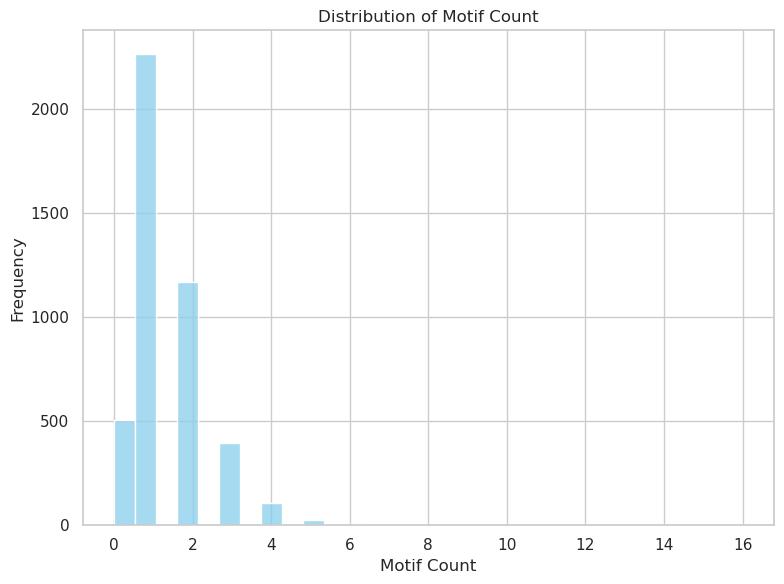

In [27]:
# Set style
sns.set(style="whitegrid")

# Plot distribution
plt.figure(figsize=(8, 6))
sns.histplot(grouped_df['motif_count'], bins=30, color="skyblue")

# Labels and title
plt.xlabel("Motif Count")
plt.ylabel("Frequency")
plt.title("Distribution of Motif Count")
plt.tight_layout()
plt.show()

In [31]:
# filtering out all the boundaries that do not have ant CTCFs in the disrupted bin

ctcf_grouped_df = grouped_df[grouped_df["motif_count"] > 0]
ctcf_grouped_df = ctcf_grouped_df[ctcf_grouped_df["motif_count"] < 7]

In [35]:
len(ctcf_grouped_df)

3963

In [36]:
ctcf_grouped_df["URQ_diff"] = ctcf_grouped_df["URQ_mean_og"] - ctcf_grouped_df["URQ_mean_perm"]

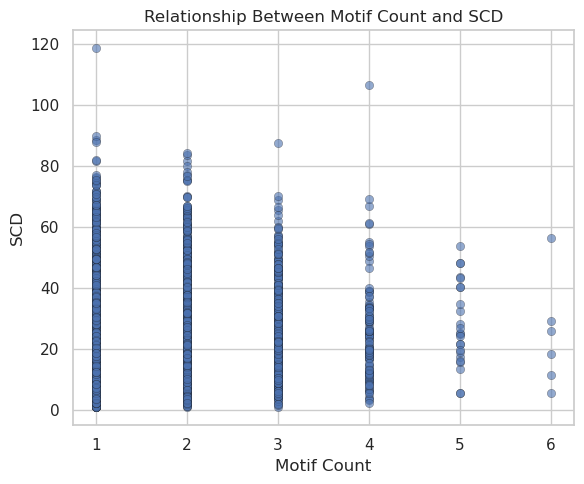

In [37]:
plt.figure(figsize=(6, 5))
plt.scatter(
    ctcf_grouped_df["motif_count"],
    ctcf_grouped_df["scd"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count and SCD")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
from scipy.stats import pearsonr

### URQ mean vs. FIMO score (mean and max)

In [40]:
x = ctcf_grouped_df["score_max"]
y = ctcf_grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [41]:
r, p = pearsonr(ctcf_grouped_df["score_max"], ctcf_grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

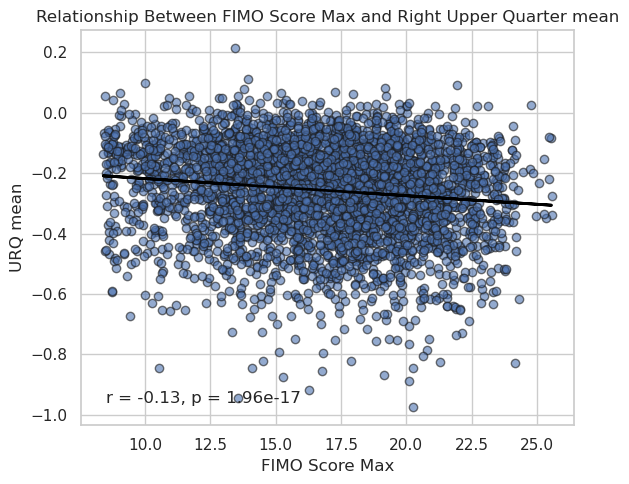

In [42]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    ctcf_grouped_df["score_max"],
    ctcf_grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.6,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Max and Right Upper Quarter mean")
plt.xlabel("FIMO Score Max")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
x = ctcf_grouped_df["score_sum"]
y = ctcf_grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [45]:
r, p = pearsonr(ctcf_grouped_df["score_sum"], ctcf_grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [46]:
len(ctcf_grouped_df)

3963

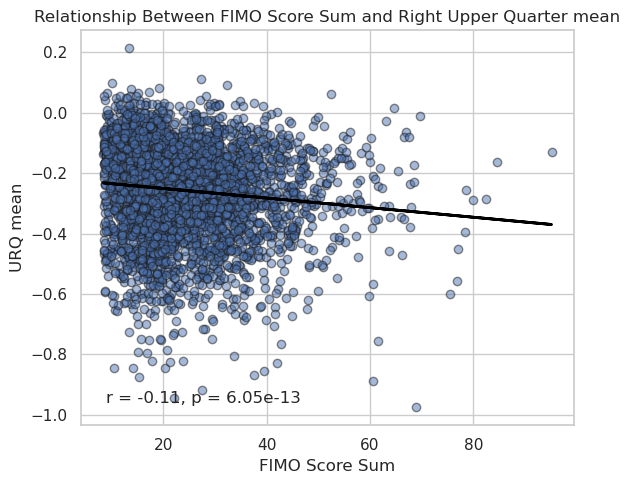

In [47]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    ctcf_grouped_df["score_sum"],
    ctcf_grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.5,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Sum and Right Upper Quarter mean")
plt.xlabel("FIMO Score Sum")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()